# Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

**Domain:** Agriculture  
**Project Theme:** Seasonal Agriculture Performance  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

### Project Goal
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

> **Important:** This is a Data Analytics project. No Machine Learning or dashboard development is required.

## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

## 2. Project Objectives

- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for analysis.
- Explore seasonal patterns.
- Perform descriptive and statistical analysis.
- Investigate relationships among relevant variables.
- Compare agricultural performance across seasons and meaningful groups.
- Use univariate, bivariate and multivariate visualizations.
- Identify significant findings from the data.
- Develop evidence-based insights and recommendations.

## 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Expected dataset:** `seasonal_agriculture_performance_dataset(1).csv`

In [55]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [56]:
# Google Colab: upload the dataset

from google.colab import files
import io

uploaded = files.upload()

csv_files = [name for name in uploaded.keys() if name.lower().endswith(".csv")]
if not csv_files:
    raise FileNotFoundError("Please upload the Seasonal Agriculture Performance CSV file.")

file_path = csv_files[0]
df = pd.read_csv(io.BytesIO(uploaded[file_path]))

print("Dataset loaded successfully.")
print("File:", file_path)
print("Shape:", df.shape)

Saving seasonal_agriculture_performance_dataset (2).csv to seasonal_agriculture_performance_dataset (2) (1).csv
Dataset loaded successfully.
File: seasonal_agriculture_performance_dataset (2) (1).csv
Shape: (4000, 28)


## 4. Initial Data Understanding

In [57]:
# Dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [58]:
# Top 5 rows

display(df.head(5))

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [59]:
# Bottom 5 rows

display(df.tail(5))

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [60]:
# Random sample of records

display(df.sample(5, random_state=42))

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [61]:
# Column names

print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [62]:
# Data types and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [63]:
# Numerical summary statistics

display(df.describe())

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [64]:
# Categorical summary

display(df.describe(include="object"))

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


## 5. Data Quality Analysis

In [65]:
# Missing values

missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage.round(2)
})

display(missing_summary[missing_summary["Missing_Count"] > 0])

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


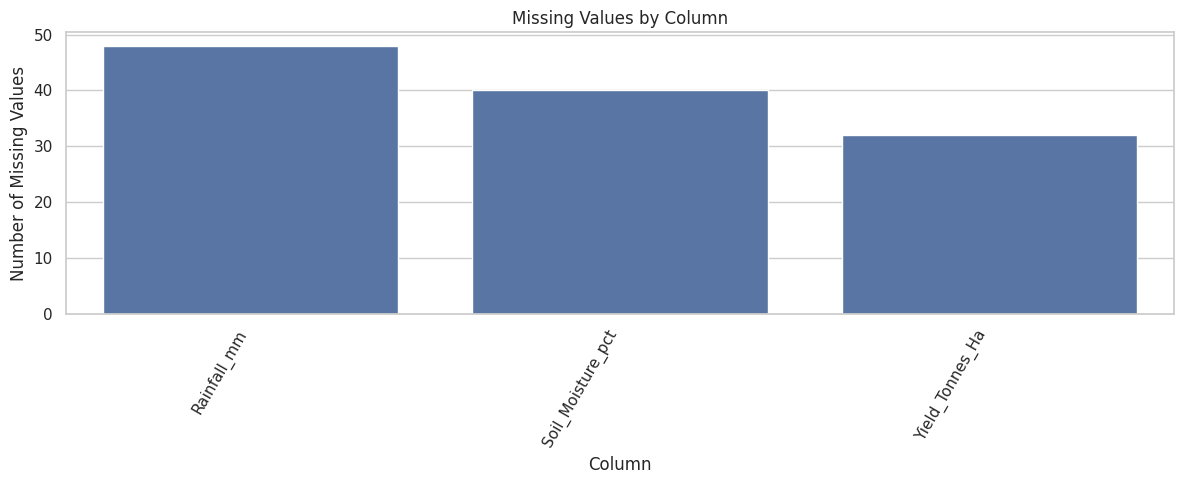

In [66]:
# Visualize missing values

plt.figure(figsize=(12, 5))
missing_plot = missing[missing > 0]

if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Number of Missing Values")
    plt.xlabel("Column")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

In [67]:
# Duplicate records

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [68]:
# Remove duplicate rows

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


In [69]:
# Check data types again

display(df.dtypes.to_frame("Data Type"))

,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [70]:
# Check unique values for categorical columns

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [71]:
# Check missing values after duplicate removal

display(df.isnull().sum().sort_values(ascending=False).head(10))

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


### Missing Value Treatment

The dataset contains missing values in selected numerical variables. Median imputation is used for numerical columns because it is simple and less sensitive to extreme observations than mean imputation.

In [72]:
# Median imputation for numerical columns

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


## 6. Feature / Variable Review

In [73]:
# Numerical and categorical columns

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


## 7. Statistical Analysis

In [74]:
# Descriptive statistics with range and IQR

stats = df[numeric_columns].describe().T
stats["Range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]

display(stats.round(2))

,count,mean,std,min,25%,50%,75%,max,Range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.90,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.78,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [75]:
# Median and standard deviation

statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std_Dev": df[numeric_columns].std(),
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max()
})

display(statistical_summary.round(2))

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.90,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [76]:
# Seasonal descriptive summary

season_summary = df.groupby("Season")[numeric_columns].agg(["mean", "median", "std"])
display(season_summary.round(2))

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.18 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

## 8. Univariate Analysis

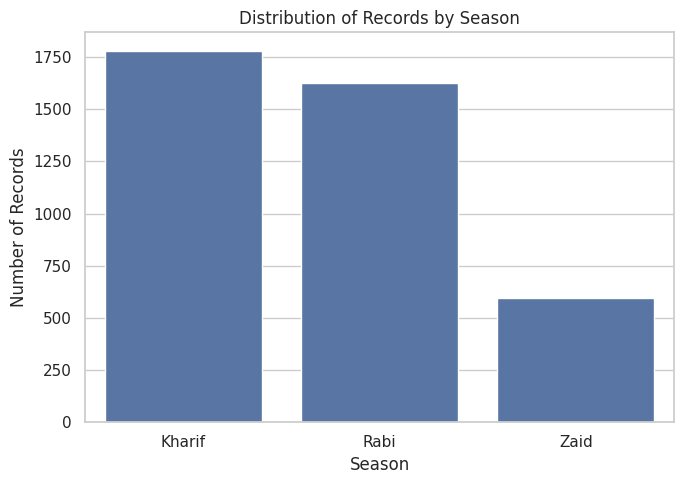

In [77]:
# Univariate: Season distribution

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Season", order=df["Season"].value_counts().index)
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

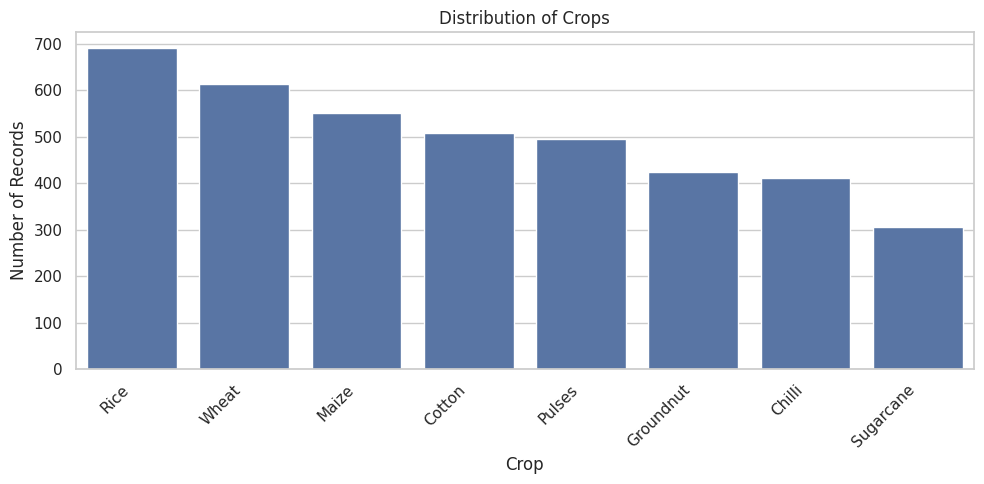

In [78]:
# Univariate: Crop distribution

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

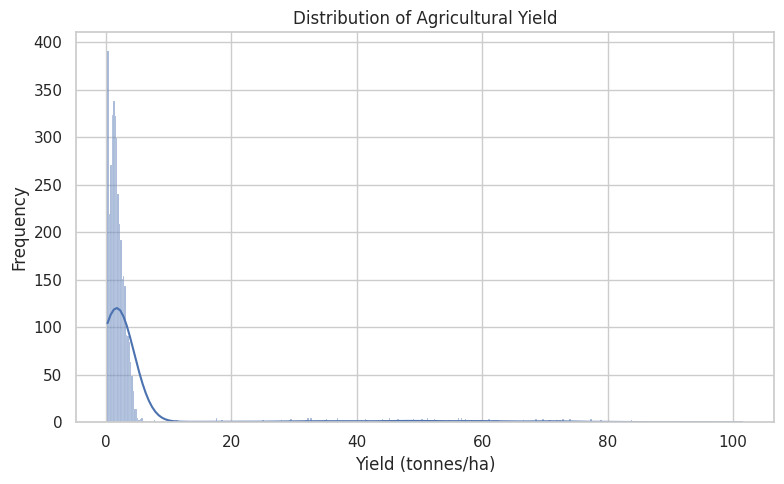

In [79]:
# Univariate: Yield distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

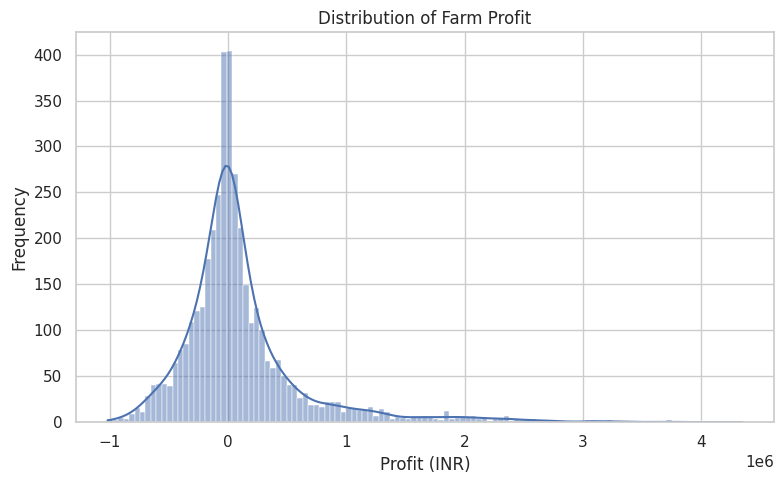

In [80]:
# Univariate: Profit distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

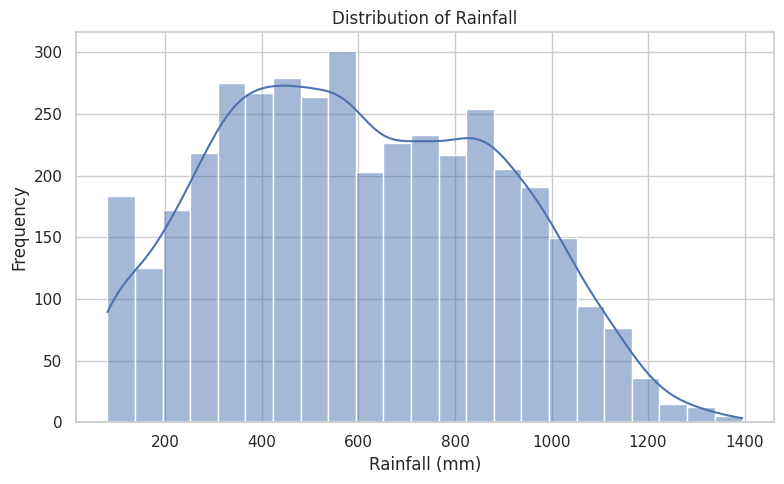

In [81]:
# Univariate: Rainfall distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

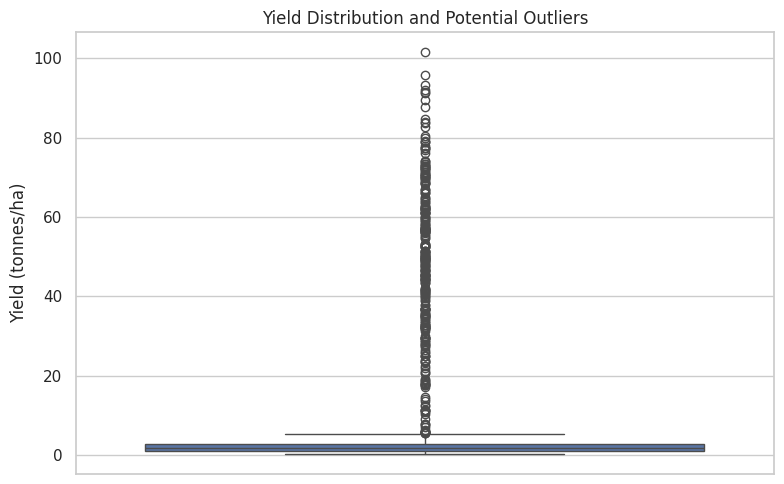

In [82]:
# Univariate: Boxplot for yield

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

## 9. Outlier Analysis

### Univariate: Season distribution (Pie Chart)

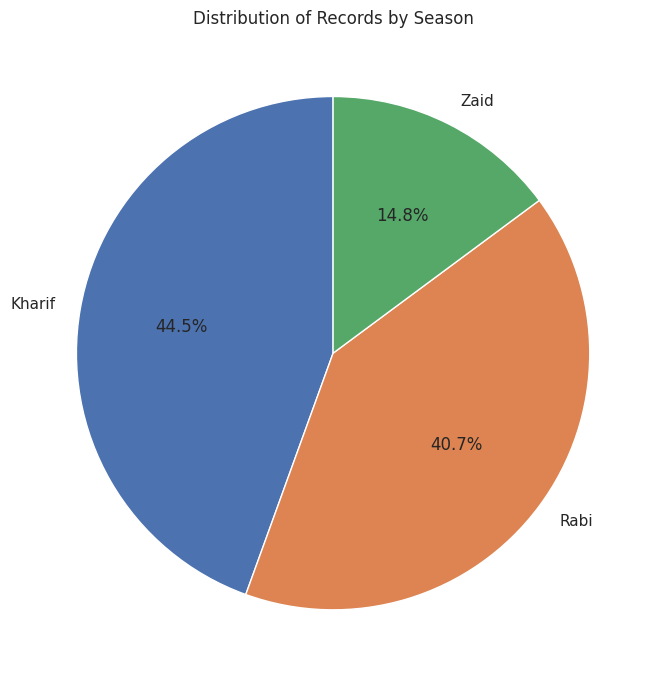

In [83]:
plt.figure(figsize=(7, 7))
df["Season"].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribution of Records by Season")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [84]:
# IQR-based outlier summary for numerical columns

outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "Outlier_Count", ascending=False
)

display(outlier_summary)

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


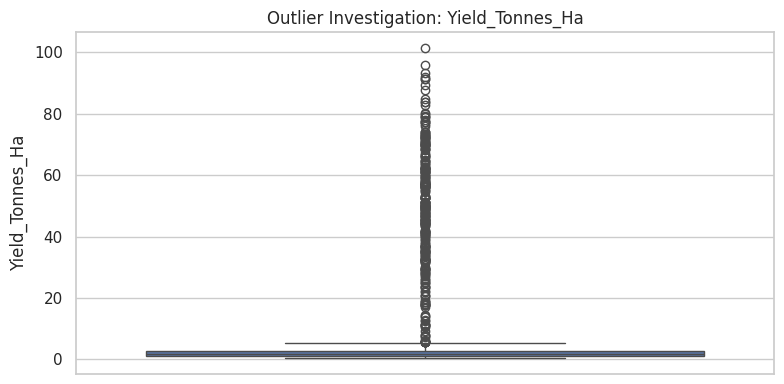

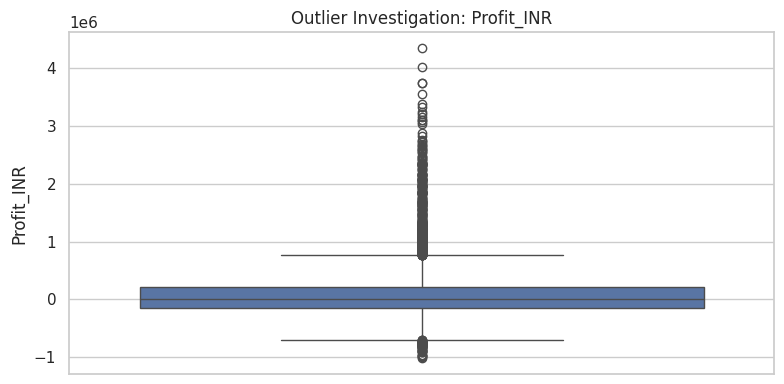

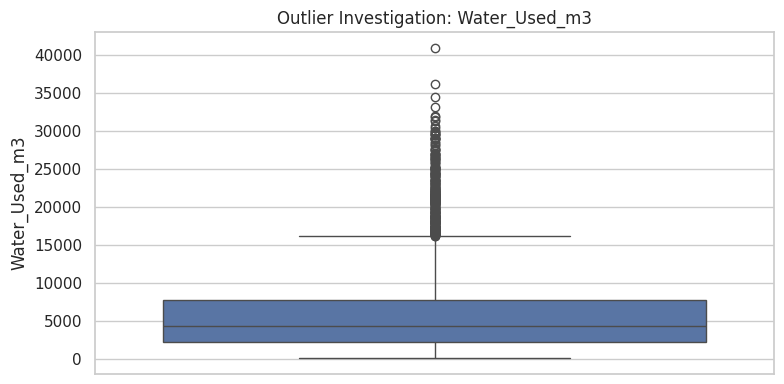

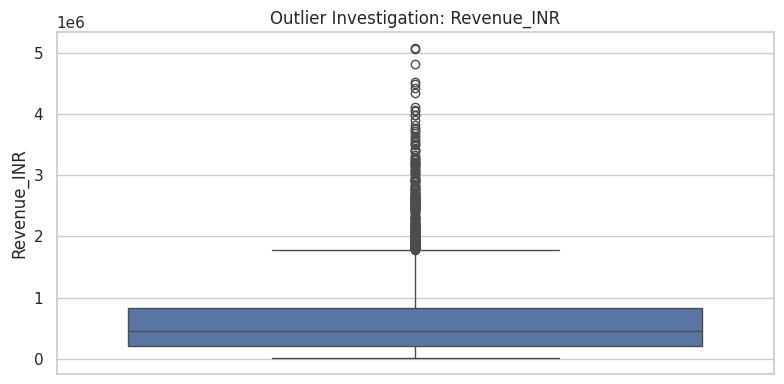

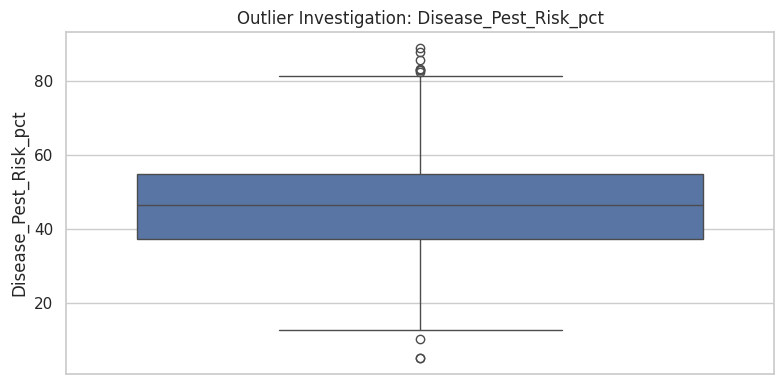

In [85]:
# Boxplots for selected variables

selected_outlier_cols = [
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Water_Used_m3",
    "Revenue_INR",
    "Disease_Pest_Risk_pct"
]

for col in selected_outlier_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, y=col)
    plt.title(f"Outlier Investigation: {col}")
    plt.tight_layout()
    plt.show()

## 10. Bivariate Analysis

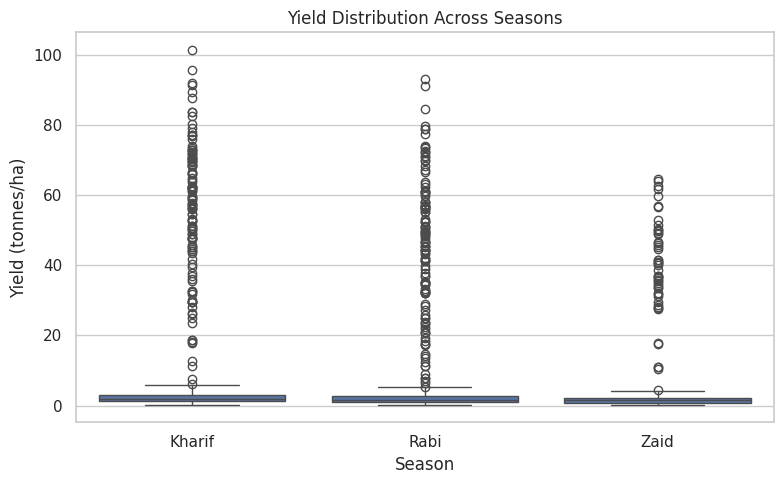

In [86]:
# Bivariate: Season vs Yield

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

### Bar plots for Bivariate Analysis

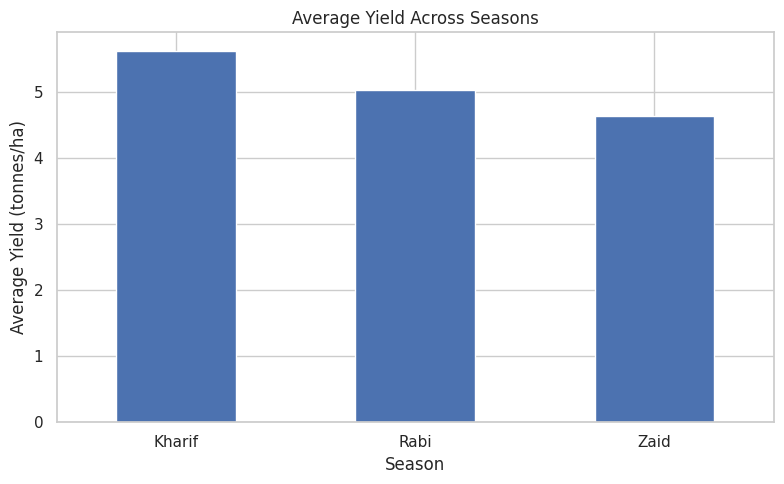

In [87]:
# Season vs average yield

season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
season_yield.plot(kind="bar")
plt.title("Average Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (tonnes/ha)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

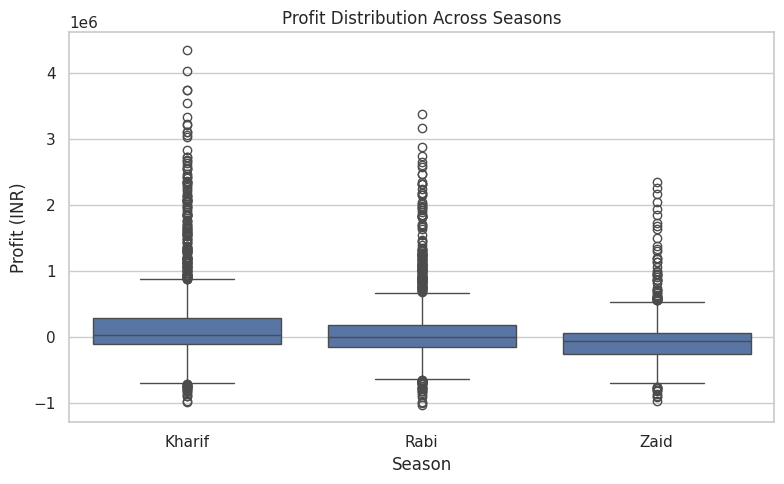

In [88]:
# Bivariate: Season vs Profit

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Profit_INR")
plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

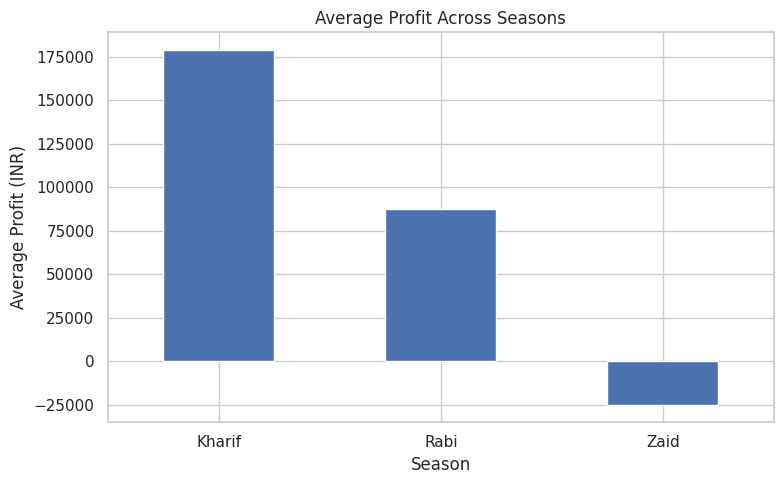

In [89]:
# Season vs average profit

season_profit = df.groupby("Season")["Profit_INR"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
season_profit.plot(kind="bar")
plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

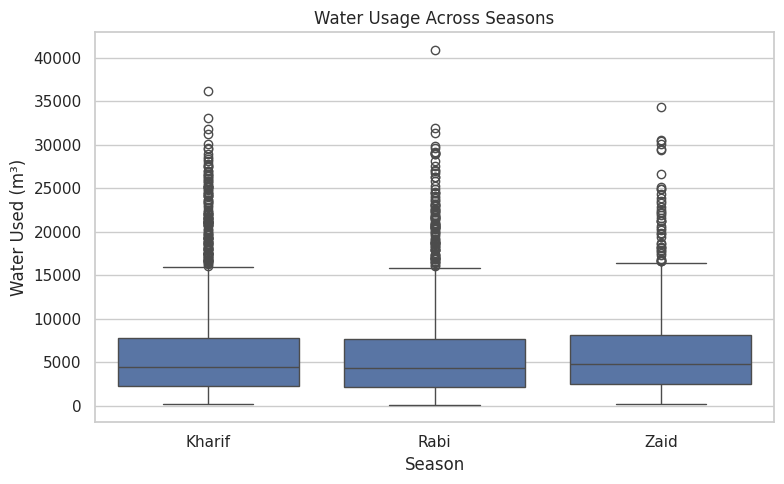

In [90]:
# Bivariate: Season vs Water Usage

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Water_Used_m3")
plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.tight_layout()
plt.show()

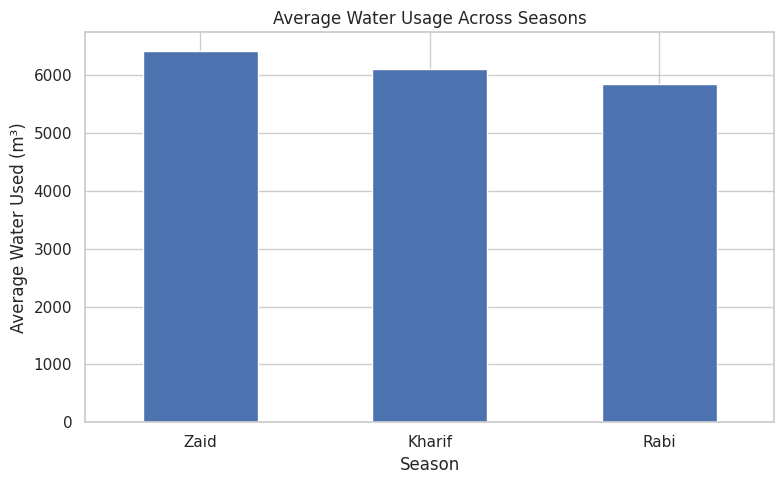

In [91]:
# Season vs average water usage

season_water = df.groupby("Season")["Water_Used_m3"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
season_water.plot(kind="bar")
plt.title("Average Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

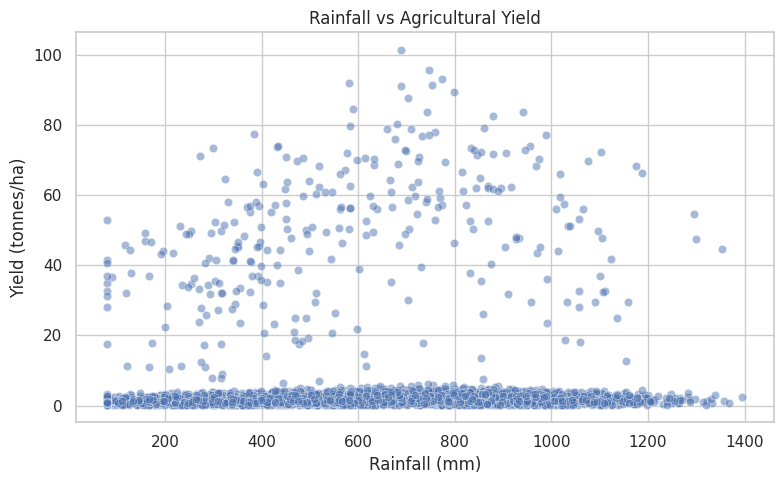

Correlation: 0.031


In [92]:
# Bivariate: Rainfall vs Yield

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.5)
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

print("Correlation:", round(df[["Rainfall_mm", "Yield_Tonnes_Ha"]].corr().iloc[0,1], 3))

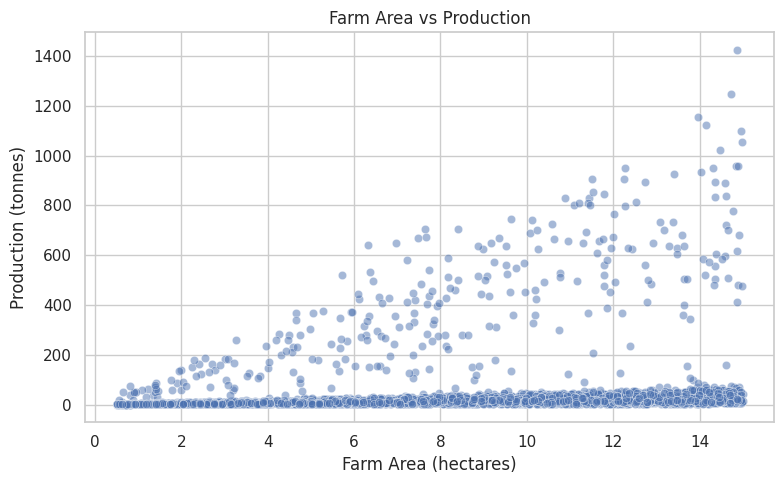

Correlation: 0.198


In [93]:
# Bivariate: Farm area vs Production

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha=0.5)
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (hectares)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()

print("Correlation:", round(df[["Farm_Area_Hectares", "Production_Tonnes"]].corr().iloc[0,1], 3))

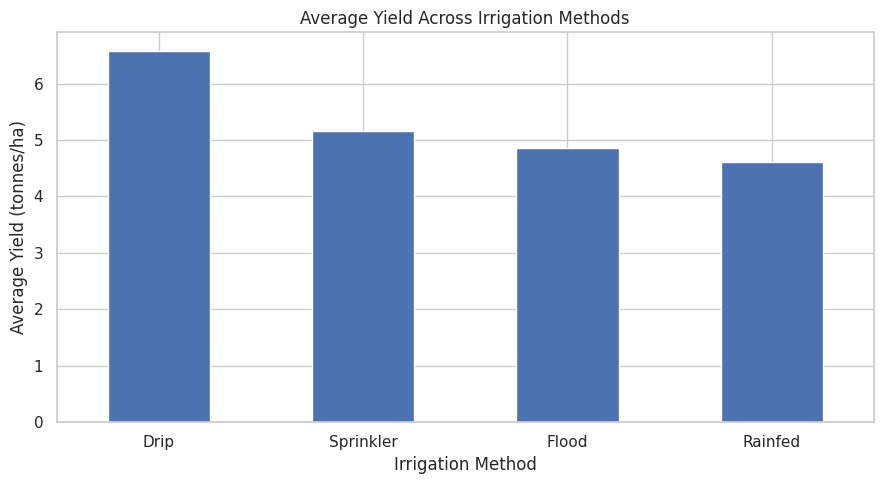

In [94]:
# Bivariate: Irrigation method vs yield

irrigation_yield = df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
irrigation_yield.plot(kind="bar")
plt.title("Average Yield Across Irrigation Methods")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (tonnes/ha)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Multivariate Analysis

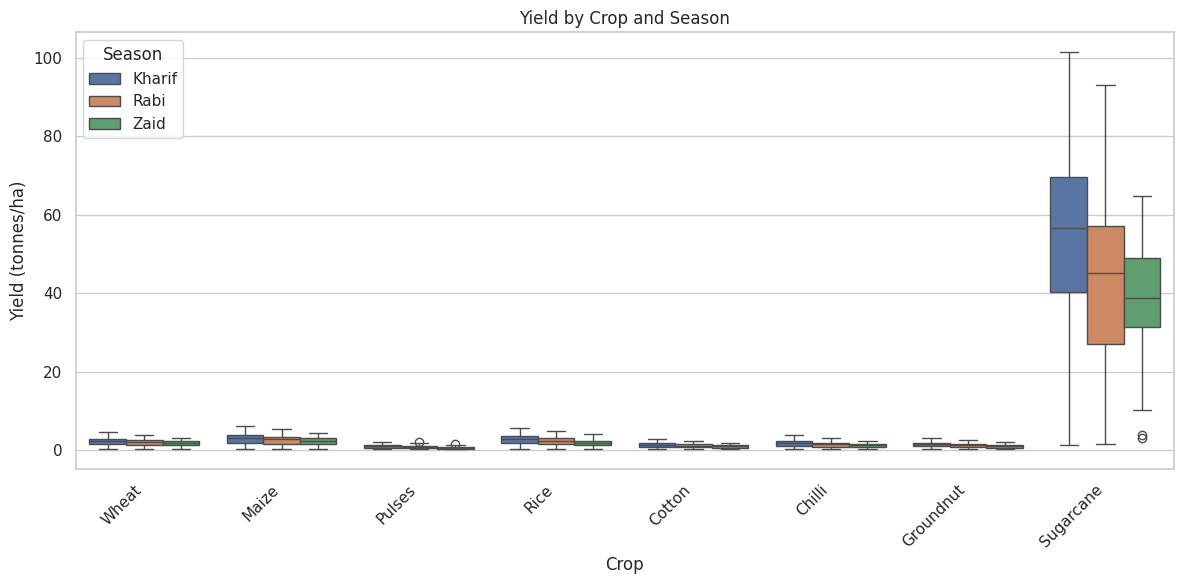

In [95]:
# Multivariate: Season, crop and yield

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

In [96]:
# Prepare crop-season summary

crop_season_summary = (
    df.groupby(["Season", "Crop"])
      .agg(
          Average_Yield=("Yield_Tonnes_Ha", "mean"),
          Average_Profit=("Profit_INR", "mean"),
          Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
      )
      .round(2)
)

display(crop_season_summary)

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Chilli              1.73      954,380.42                      3.26
       Cotton              1.37      216,999.55                      2.13
       Groundnut           1.48      108,265.44                      3.58
       Maize               2.97      -39,332.67                      6.05
       Pulses              1.04       43,338.90                      3.35
       Rice                2.70      -64,903.40                      2.17
       Sugarcane          53.46    1,000,790.81                     36.00
       Wheat               2.25     -105,871.87                      4.76
Rabi   Chilli              1.47      638,572.50                      2.89
       Cotton              1.20      107,343.59                      1.94
       Groundnut           1.23       10,416.54                      2.90
       Maize               2.60      -89,133.40                      5.46
       Pulses              0.88      -14,309.14                      2.70
       Rice                2.32      -98,427.87                      1.84
       Sugarcane          43.29      731,612.86                     27.92
       Wheat               2.06     -119,954.57                      4.69
Zaid   Chilli              1.20      448,659.09                      2.20
       Cotton              0.96      -53,925.34                      1.49
       Groundnut           1.04      -68,872.50                      2.47
       Maize               2.29     -194,049.17                      4.75
       Pulses              0.67     -139,227.81                      1.95
       Rice                1.90     -227,239.34                      1.53
       Sugarcane          38.42      583,635.80                     23.39
       Wheat               1.75     -193,208.95                      4.02

### Multivariate: Grouped Bar Plot of Average Yield by Crop and Season

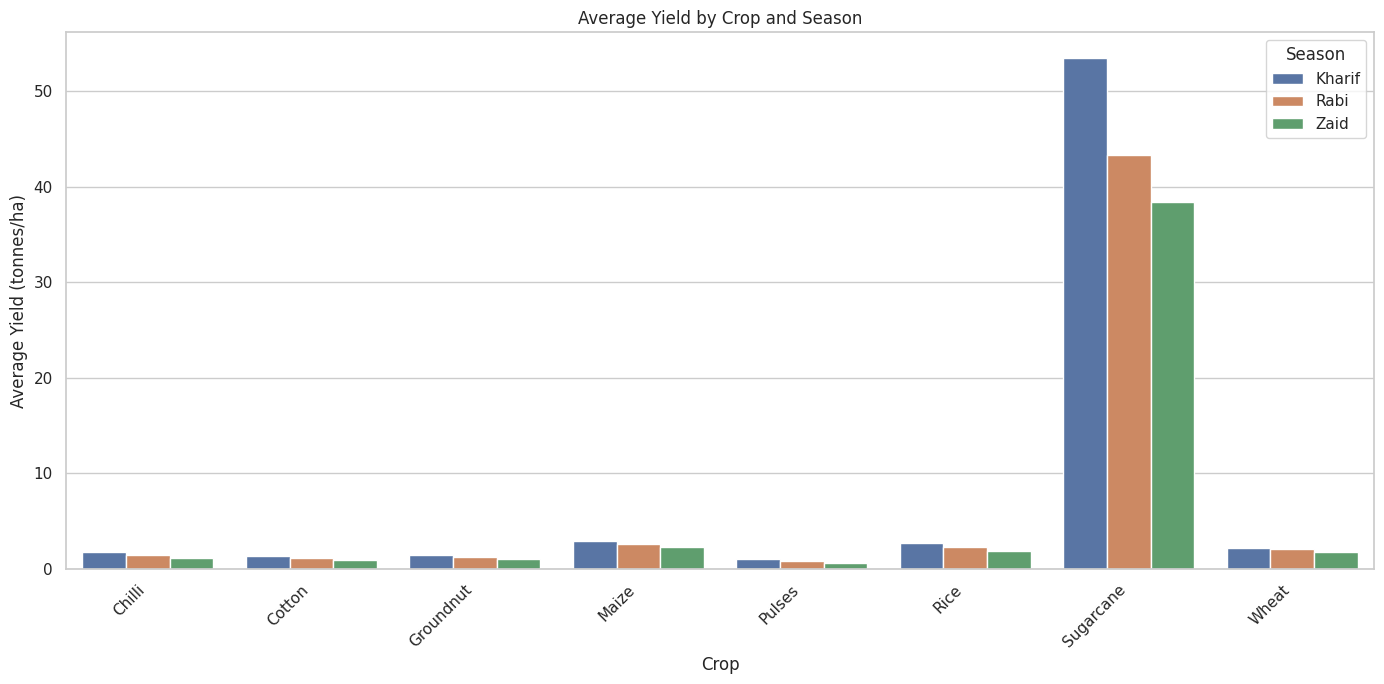

In [97]:
plot_data = crop_season_summary.reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(
    data=plot_data,
    x="Crop",
    y="Average_Yield",
    hue="Season",
    errorbar=None
)
plt.title("Average Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Average Yield (tonnes/ha)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

### Multivariate: Pair Plot of Key Environmental and Performance Metrics by Season

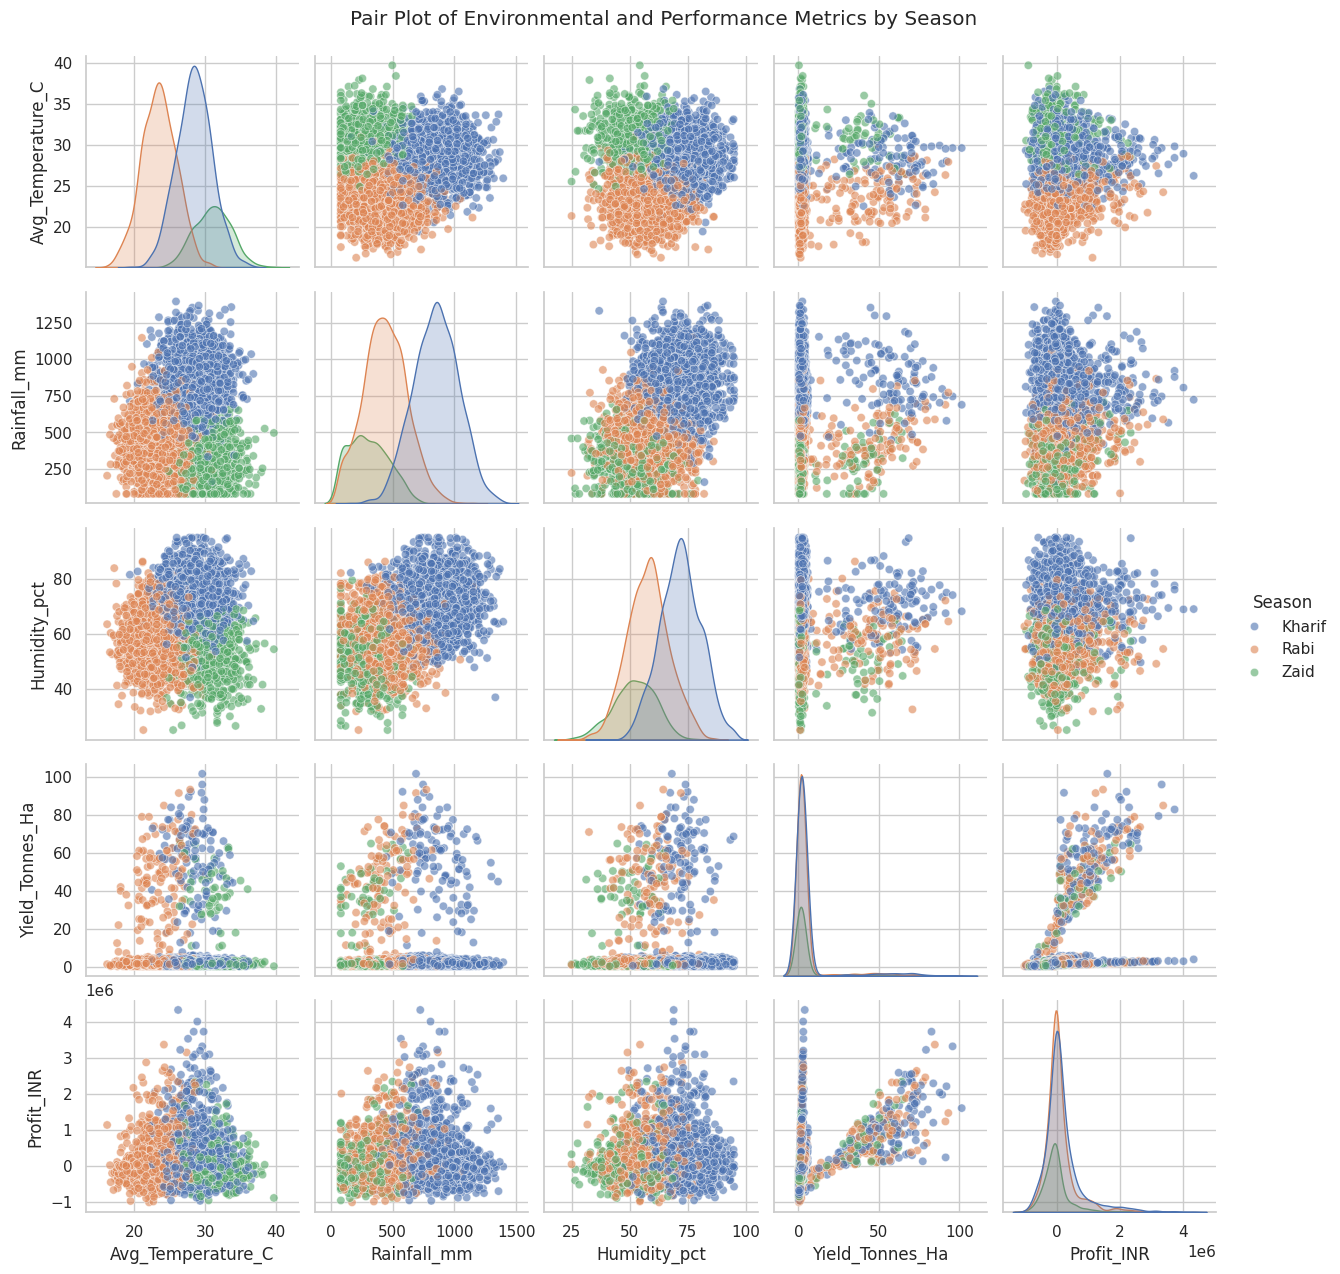

In [98]:
selected_columns = [
    "Avg_Temperature_C",
    "Rainfall_mm",
    "Humidity_pct",
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Season"
]

sns.pairplot(
    df[selected_columns],
    hue="Season",
    plot_kws={"alpha": 0.6}
)
plt.suptitle(
    "Pair Plot of Environmental and Performance Metrics by Season",
    y=1.02
)
plt.show()

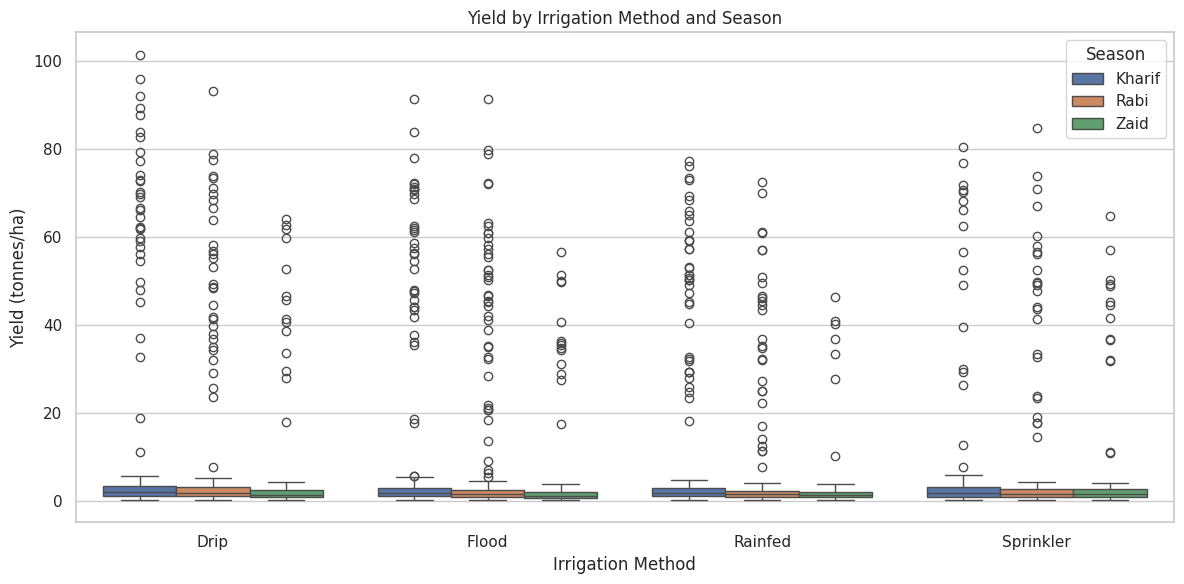

In [99]:
# Multivariate: Season, irrigation and yield

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    hue="Season"
)
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

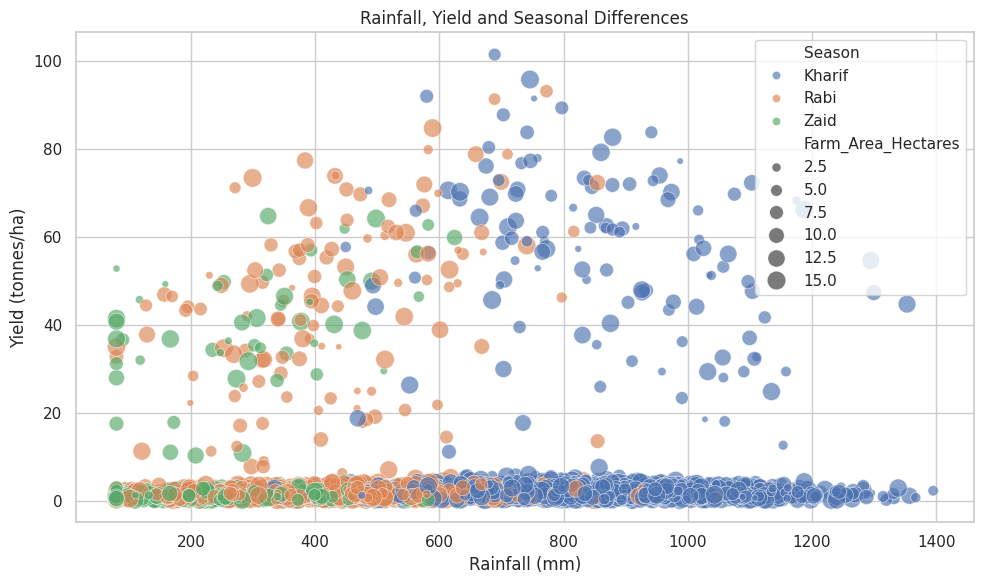

In [100]:
# Multivariate: Rainfall, yield and season

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

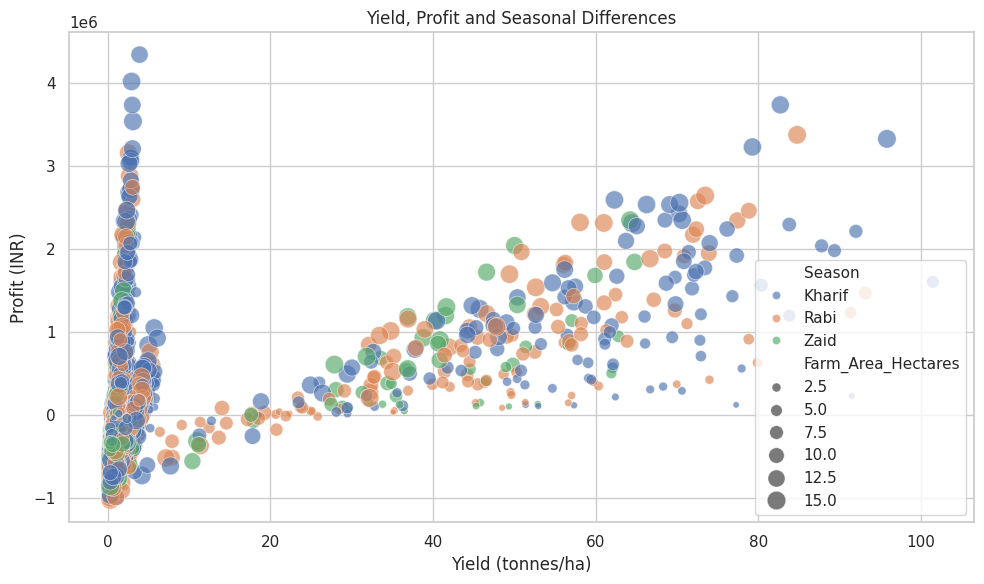

In [101]:
# Multivariate: Profit, yield and season

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

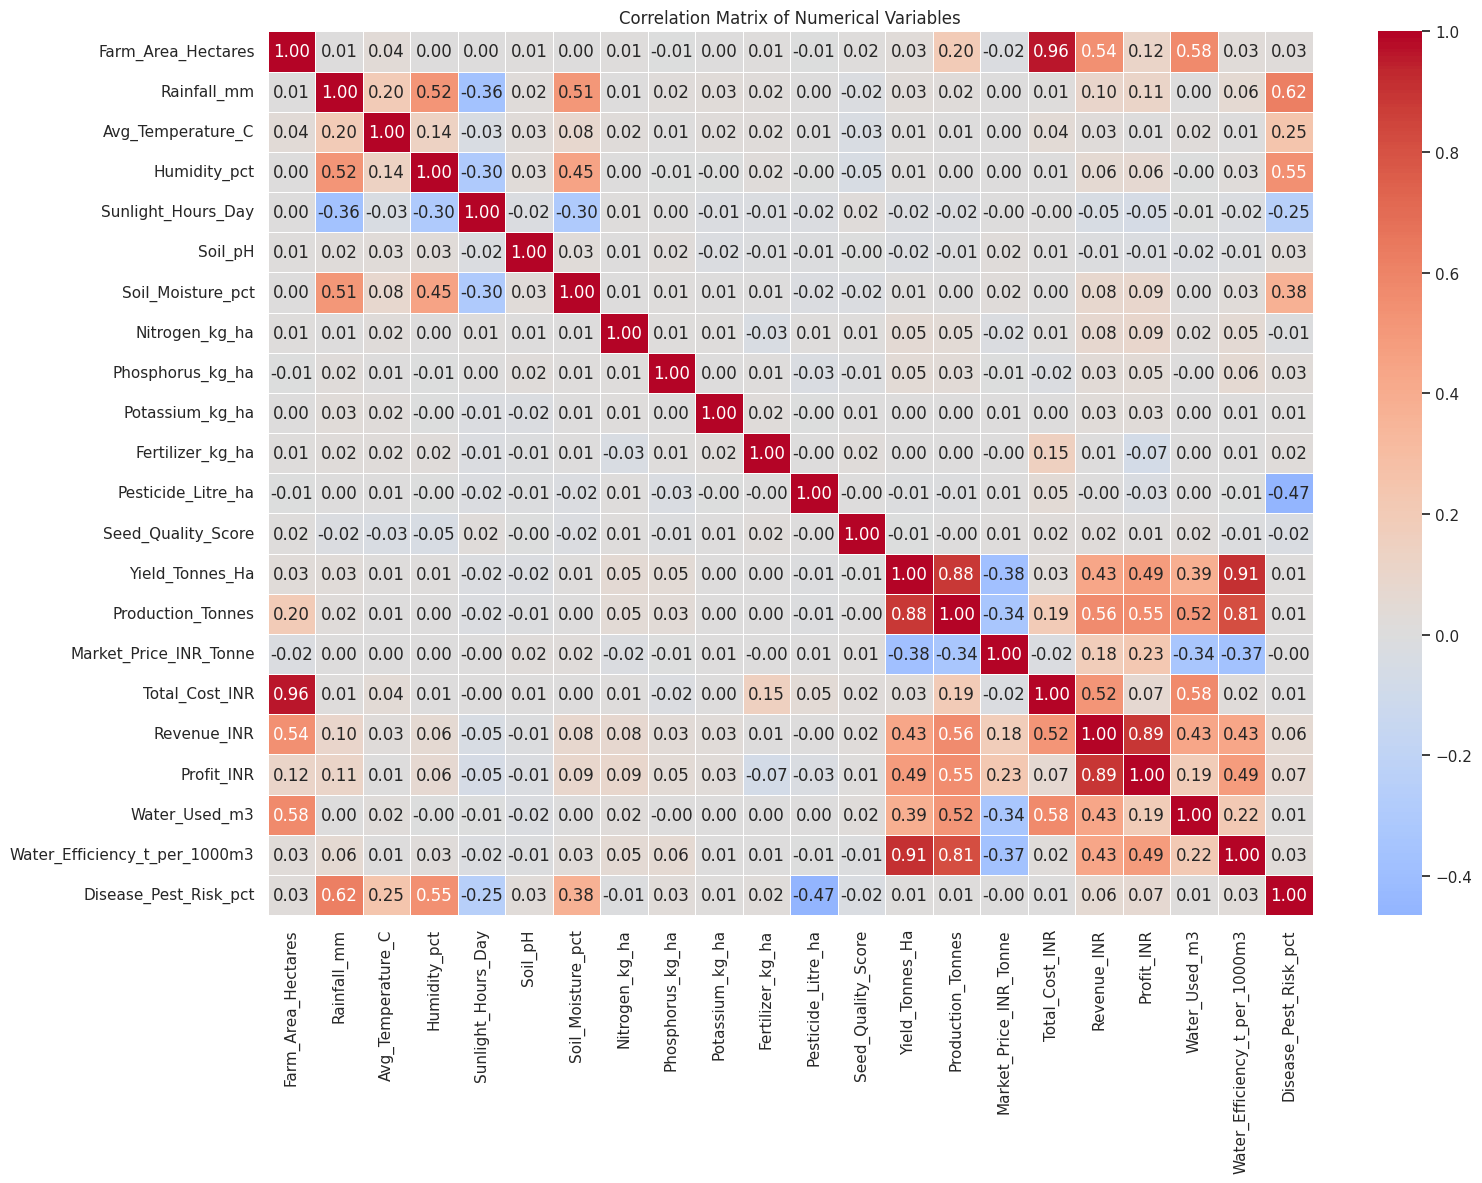

In [102]:
# Correlation heatmap for numerical variables

plt.figure(figsize=(16, 12))
corr = df[numeric_columns].corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

## 12. Seasonal Comparison

In [103]:
# General seasonal summary

season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Rainfall=("Rainfall_mm", "mean"),
    Average_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

display(season_metrics)

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used,Average_Water_Efficiency,Average_Rainfall,Average_Disease_Risk
Season,,,,,,,,,
Kharif,1779,5.63,"82,387.61","178,914.65",318289158,"6,102.20",5.89,849.20,54.47
Rabi,1627,5.04,"67,498.88","87,689.47",142670768,"5,846.99",5.19,437.62,40.48
Zaid,594,4.64,"23,098.35","-24,804.82",-14734066,"6,419.89",4.41,304.65,38.22


In [104]:
# Compare crop performance within each season

crop_season_summary = (
    df.groupby(["Season", "Crop"])
      .agg(
          Average_Yield=("Yield_Tonnes_Ha", "mean"),
          Average_Profit=("Profit_INR", "mean"),
          Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
      )
      .round(2)
      .sort_values(["Season", "Average_Yield"], ascending=[True, False])
)

display(crop_season_summary)

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46    1,000,790.81                     36.00
       Maize               2.97      -39,332.67                      6.05
       Rice                2.70      -64,903.40                      2.17
       Wheat               2.25     -105,871.87                      4.76
       Chilli              1.73      954,380.42                      3.26
       Groundnut           1.48      108,265.44                      3.58
       Cotton              1.37      216,999.55                      2.13
       Pulses              1.04       43,338.90                      3.35
Rabi   Sugarcane          43.29      731,612.86                     27.92
       Maize               2.60      -89,133.40                      5.46
       Rice                2.32      -98,427.87                      1.84
       Wheat               2.06     -119,954.57                      4.69
       Chilli              1.47      638,572.50                      2.89
       Groundnut           1.23       10,416.54                      2.90
       Cotton              1.20      107,343.59                      1.94
       Pulses              0.88      -14,309.14                      2.70
Zaid   Sugarcane          38.42      583,635.80                     23.39
       Maize               2.29     -194,049.17                      4.75
       Rice                1.90     -227,239.34                      1.53
       Wheat               1.75     -193,208.95                      4.02
       Chilli              1.20      448,659.09                      2.20
       Groundnut           1.04      -68,872.50                      2.47
       Cotton              0.96      -53,925.34                      1.49
       Pulses              0.67     -139,227.81                      1.95

In [105]:
# Best-performing crop in each season by average yield

best_crop_each_season = (
    crop_season_summary.reset_index()
    .sort_values(["Season", "Average_Yield"], ascending=[True, False])
    .groupby("Season")
    .head(1)
)

display(best_crop_each_season)

,Season,Crop,Average_Yield,Average_Profit,Average_Water_Efficiency
0,Kharif,Sugarcane,53.46,"1,000,790.81",36.00
8,Rabi,Sugarcane,43.29,"731,612.86",27.92
16,Zaid,Sugarcane,38.42,"583,635.80",23.39


## 13. Additional Student-Driven Analysis

### Student Analysis 1 — Irrigation Performance

**Question:** Which irrigation method gives the best balance of yield, profit and water efficiency?

**Why it matters:** Irrigation is an important resource-use decision, so comparing several performance measures gives a more complete picture than looking at yield alone.

,Records,Average_Yield,Average_Profit,Average_Water_Used,Average_Water_Efficiency
Irrigation_Method,,,,,
Drip,915,6.58,"219,626.00","5,918.75",6.27
Sprinkler,734,5.16,"91,121.08","6,208.26",4.67
Flood,1310,4.86,"73,354.02","8,026.47",3.44
Rainfed,1041,4.60,"79,050.37","3,549.55",7.56


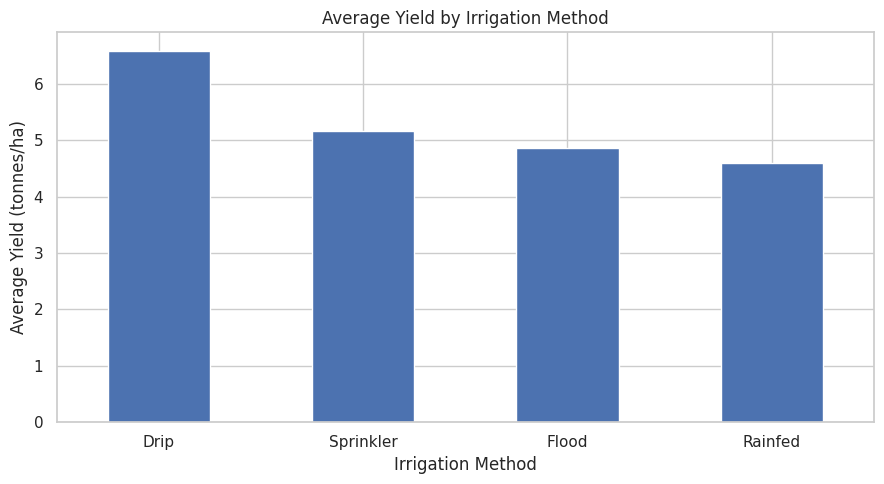

In [106]:
irrigation_summary = df.groupby("Irrigation_Method").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).round(2)

display(irrigation_summary.sort_values("Average_Yield", ascending=False))

fig, ax = plt.subplots(figsize=(9, 5))
irrigation_summary["Average_Yield"].sort_values(ascending=False).plot(
    kind="bar", ax=ax
)
ax.set_title("Average Yield by Irrigation Method")
ax.set_xlabel("Irrigation Method")
ax.set_ylabel("Average Yield (tonnes/ha)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Student Analysis 2 — Crop Profitability

**Question:** Which crops provide the strongest average economic performance?

This compares average yield, revenue, cost and profit so that crop performance is not judged from yield alone.

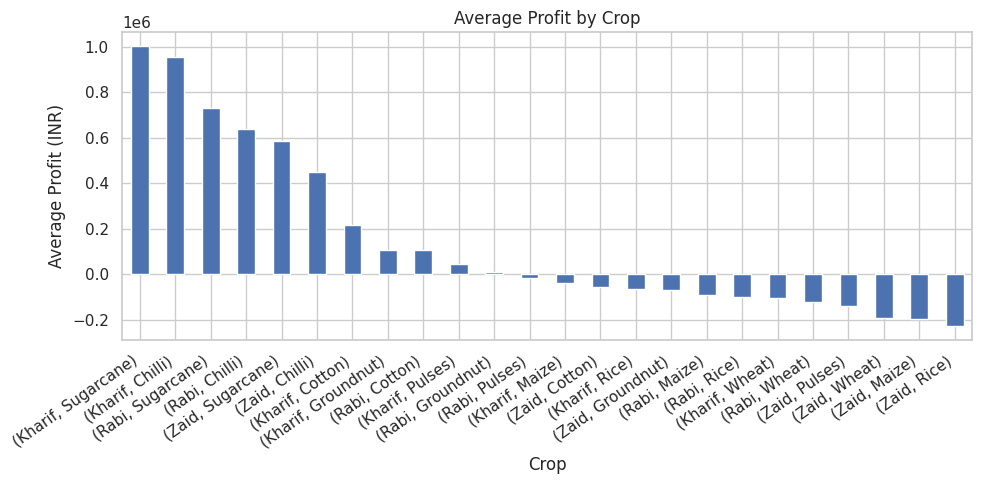

In [108]:
# Average profit by crop

plt.figure(figsize=(10, 5))
crop_season_summary["Average_Profit"].sort_values(ascending=False).plot(kind="bar")
plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### Student Analysis 3 — Profit Margin by Season

**Question:** Which season converts revenue into profit most effectively?

Profit margin is calculated as:

**Profit Margin (%) = Profit / Revenue × 100**

This provides an additional economic measure beyond absolute profit.

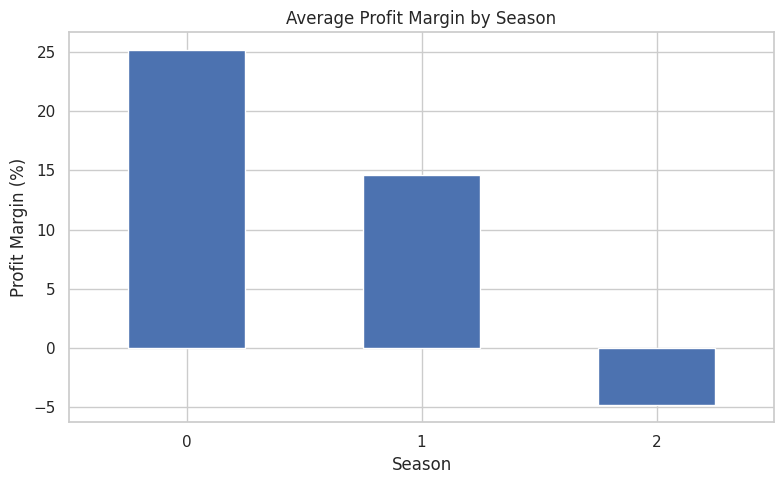

In [110]:
# Average profit margin by season

season_profitability = df.groupby('Season').agg(
    Total_Profit=('Profit_INR', 'sum'),
    Total_Revenue=('Revenue_INR', 'sum')
).reset_index()

season_profitability['Profit_Margin_pct'] = (
    season_profitability['Total_Profit'] / season_profitability['Total_Revenue']
) * 100

plt.figure(figsize=(8, 5))
season_profitability["Profit_Margin_pct"].sort_values(ascending=False).plot(kind="bar")
plt.title("Average Profit Margin by Season")
plt.xlabel("Season")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Student Analysis 4 — Seed Quality and Yield

**Question:** Is higher seed quality associated with higher yield?

This analysis uses a scatter plot and correlation coefficient to examine the relationship.

Correlation between seed quality and yield: -0.007


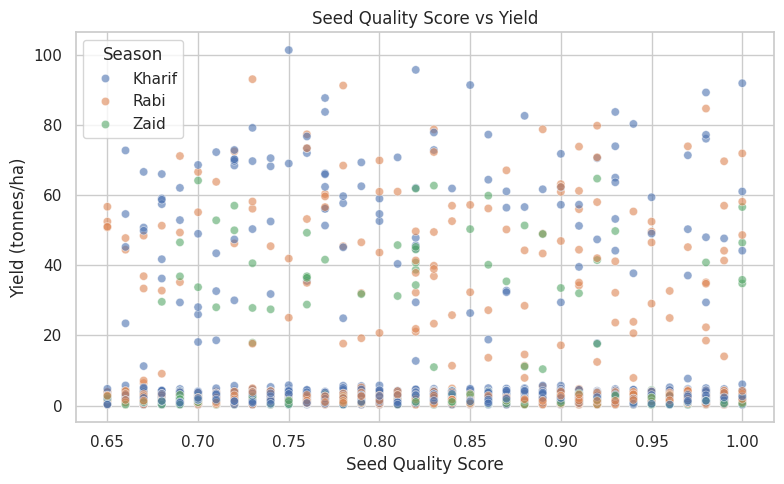

In [111]:
seed_corr = df[["Seed_Quality_Score", "Yield_Tonnes_Ha"]].corr().iloc[0, 1]
print("Correlation between seed quality and yield:", round(seed_corr, 3))

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Seed_Quality_Score",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.6
)
plt.title("Seed Quality Score vs Yield")
plt.xlabel("Seed Quality Score")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

## 14. Key Insights

The following insights are generated from the supplied dataset:

1. **Kharif has the highest average yield** among the three seasons.
2. **Kharif also has the highest average profit**, while Zaid has the lowest average profit.
3. **Zaid has the highest average water usage**, despite having the lowest average yield.
4. **Drip irrigation has the highest average yield and average profit** among the irrigation methods.
5. **Rainfed farming has the highest average water efficiency**, showing that water efficiency and absolute yield are different performance measures.
6. **Sugarcane has exceptionally high average yield and profit** compared with the other crops in the dataset.
7. Yield has a **strong positive relationship with water-efficiency measures** in the available data.
8. Farm area and production show a strong positive relationship, meaning larger farm areas generally correspond to higher total production.
9. Kharif has the **highest average rainfall and disease/pest risk**, so high seasonal performance should still be considered alongside risk.
10. Seasonal performance differs across crops, indicating that crop choice and season should be analyzed together rather than independently.

In [112]:
# Automatically generate a compact evidence table for the key insights

insight_evidence = pd.DataFrame({
    "Metric": [
        "Average Yield",
        "Average Profit",
        "Average Water Used",
        "Average Water Efficiency",
        "Average Rainfall",
        "Average Disease/Pest Risk"
    ],
    "Kharif": [
        season_metrics.loc["Kharif", "Average_Yield"],
        season_metrics.loc["Kharif", "Average_Profit"],
        season_metrics.loc["Kharif", "Average_Water_Used"],
        season_metrics.loc["Kharif", "Average_Water_Efficiency"],
        season_metrics.loc["Kharif", "Average_Rainfall"],
        season_metrics.loc["Kharif", "Average_Disease_Risk"]
    ],
    "Rabi": [
        season_metrics.loc["Rabi", "Average_Yield"],
        season_metrics.loc["Rabi", "Average_Profit"],
        season_metrics.loc["Rabi", "Average_Water_Used"],
        season_metrics.loc["Rabi", "Average_Water_Efficiency"],
        season_metrics.loc["Rabi", "Average_Rainfall"],
        season_metrics.loc["Rabi", "Average_Disease_Risk"]
    ],
    "Zaid": [
        season_metrics.loc["Zaid", "Average_Yield"],
        season_metrics.loc["Zaid", "Average_Profit"],
        season_metrics.loc["Zaid", "Average_Water_Used"],
        season_metrics.loc["Zaid", "Average_Water_Efficiency"],
        season_metrics.loc["Zaid", "Average_Rainfall"],
        season_metrics.loc["Zaid", "Average_Disease_Risk"]
    ]
}).round(2)

display(insight_evidence)

,Metric,Kharif,Rabi,Zaid
0,Average Yield,5.63,5.04,4.64
1,Average Profit,"178,914.65","87,689.47","-24,804.82"
2,Average Water Used,"6,102.20","5,846.99","6,419.89"
3,Average Water Efficiency,5.89,5.19,4.41
4,Average Rainfall,849.20,437.62,304.65
5,Average Disease/Pest Risk,54.47,40.48,38.22


## 15. Recommendations

Based on the evidence from the dataset:

- Use **season-specific planning** because yield, profit, rainfall, water use and risk differ across seasons.
- Consider **drip irrigation** where suitable because it shows strong average yield and profit performance in this dataset.
- Do not evaluate irrigation only by yield; also consider **water efficiency and water consumption**.
- Pay particular attention to **Zaid-season water management**, because Zaid shows the highest average water use and lowest average yield.
- Monitor **Kharif disease/pest risk** while taking advantage of its stronger average agricultural performance.
- Consider crop-specific strategies because crop performance changes across seasons.
- Use both **yield and economic measures** such as revenue, cost, profit and profit margin when evaluating agricultural performance.
- Treat unusually high or low observations carefully because outliers can influence averages.
- These recommendations should be validated with local farm conditions before being used for real-world decisions.

## 16. Limitations

- The dataset is observational, so relationships should not be treated as causal effects.
- Missing numerical values were handled using median imputation.
- Extreme observations may influence mean-based comparisons.
- The dataset may not capture every real-world factor affecting agricultural outcomes.
- Recommendations should therefore be treated as evidence-based guidance from this dataset rather than guaranteed outcomes.

## 17. Conclusion

The analysis shows clear differences in agricultural performance across Kharif, Rabi and Zaid seasons. Kharif records the strongest average yield and profit, while Zaid records weaker average performance and higher average water use.

The analysis also shows that irrigation method, crop selection, environmental conditions, water efficiency and disease/pest risk are important dimensions of agricultural performance.

Overall, the dataset supports **season-specific planning, efficient resource management, crop-aware decision-making and risk monitoring**. The findings describe patterns and relationships in the available data; they should not be interpreted as proof of causation.